- 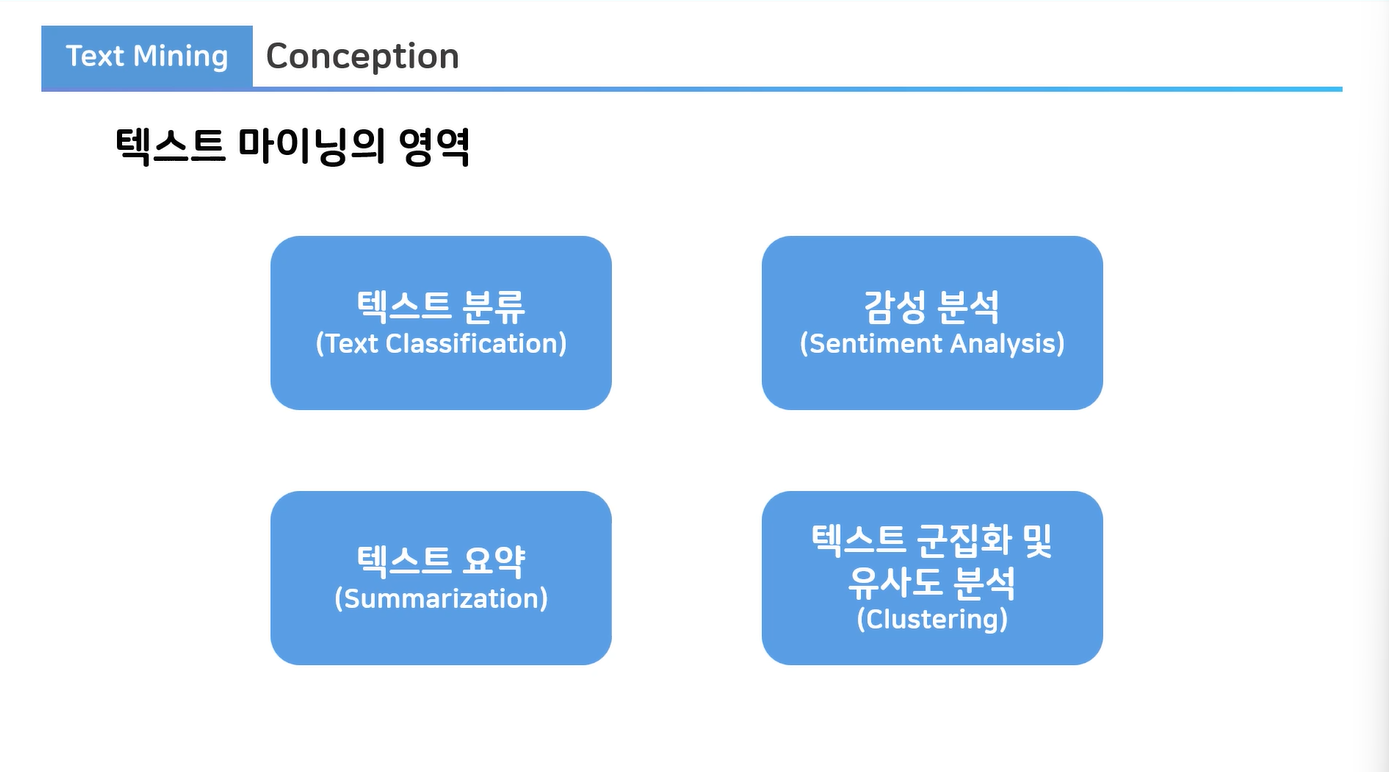 

- 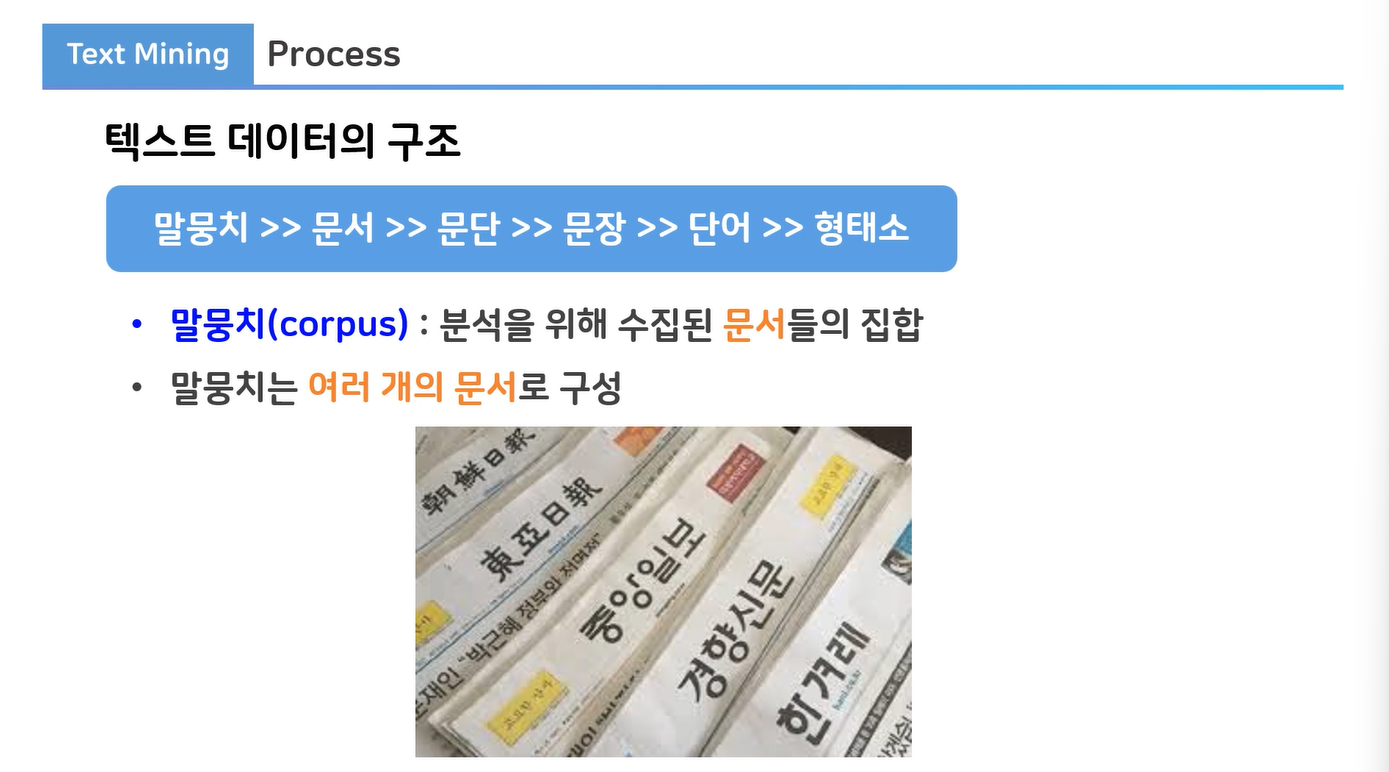 

- 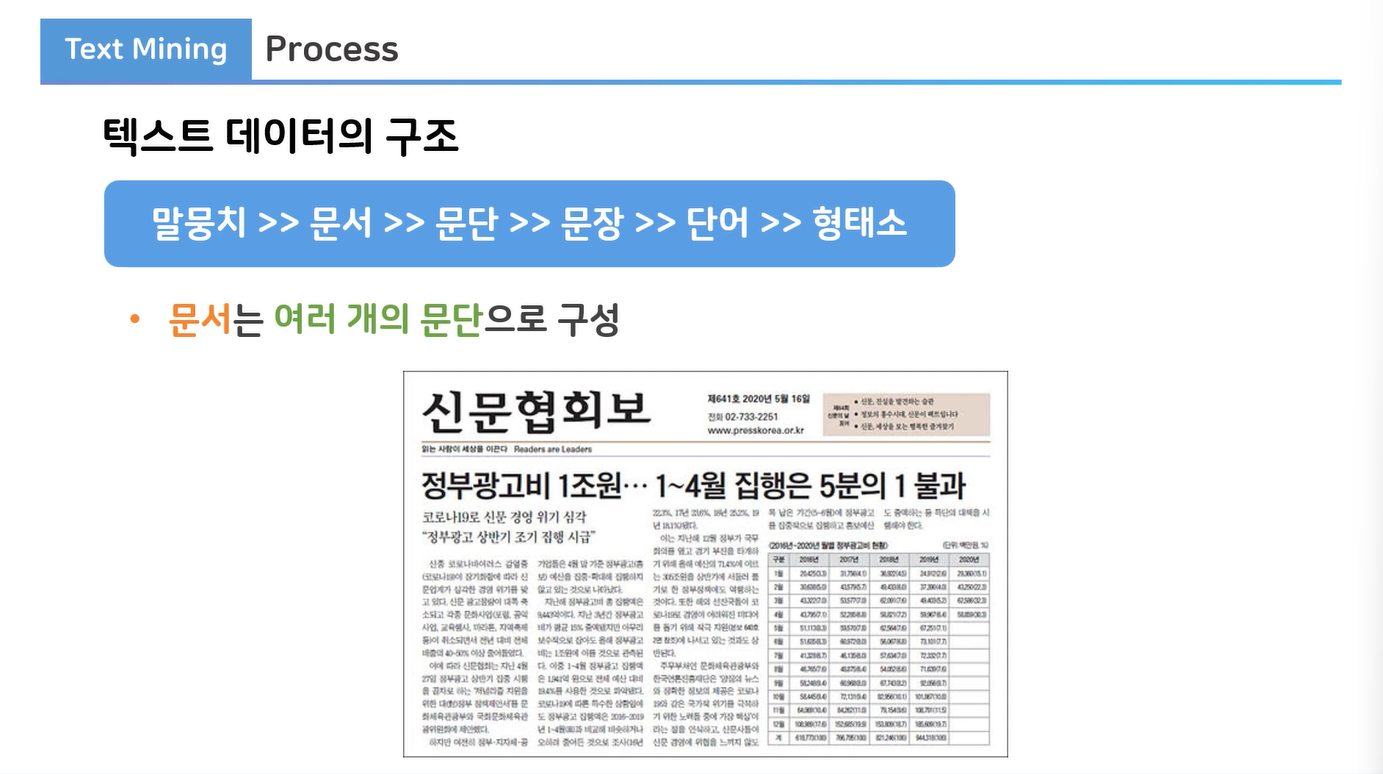
- 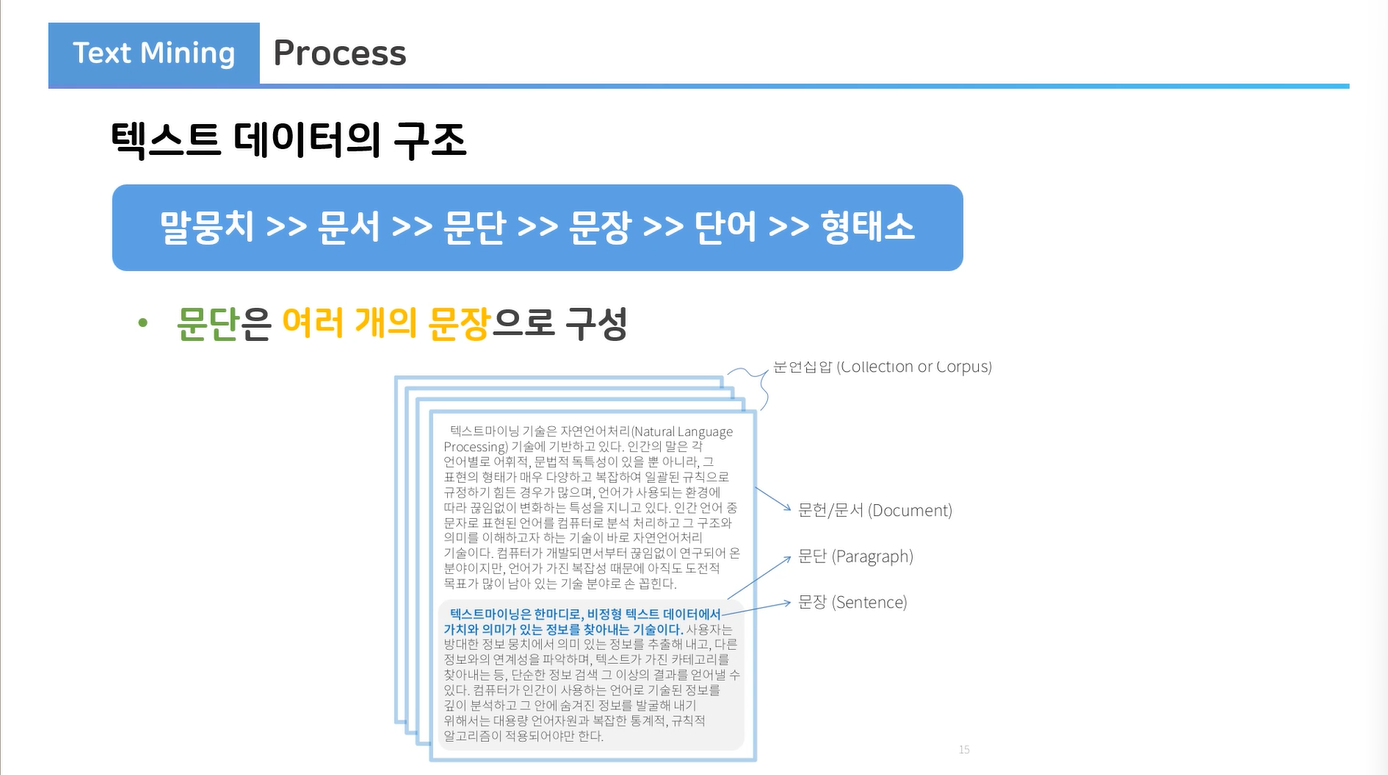
- 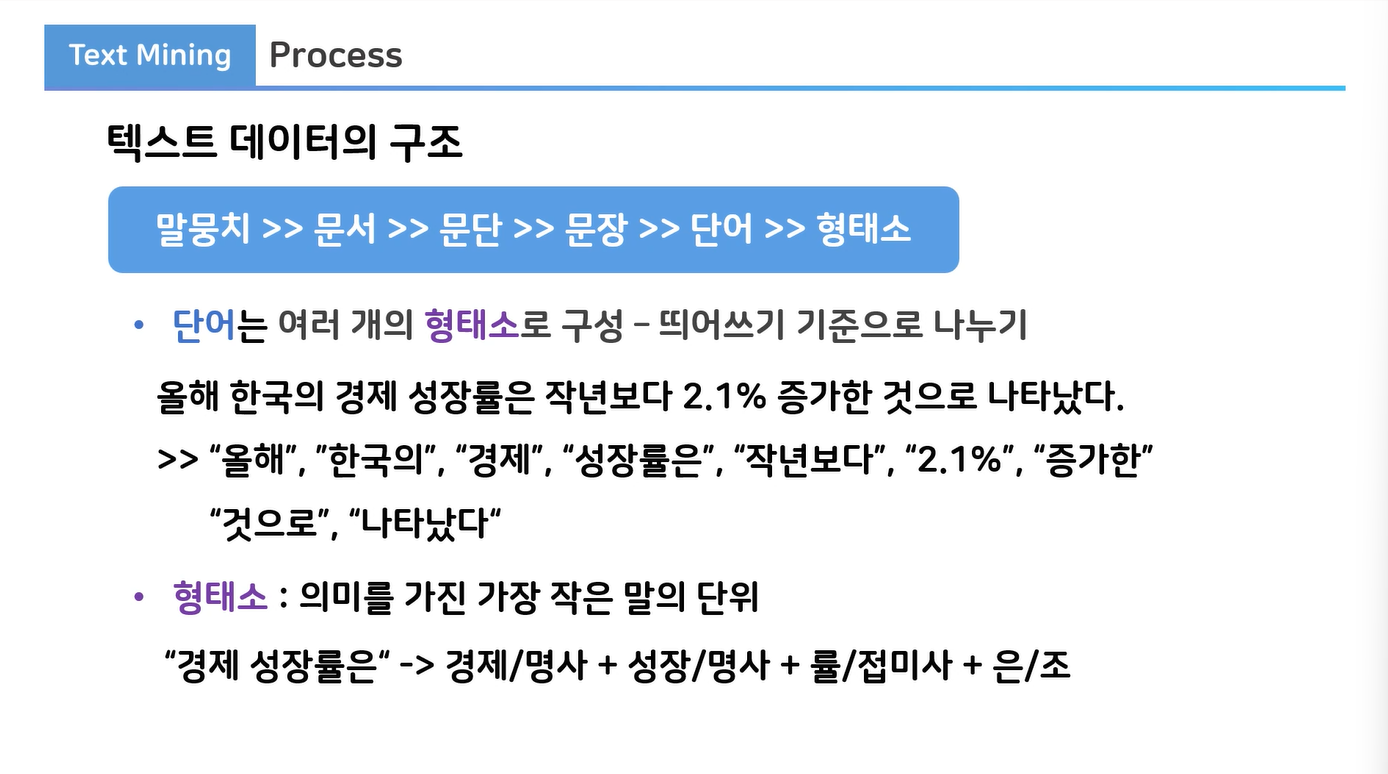

- 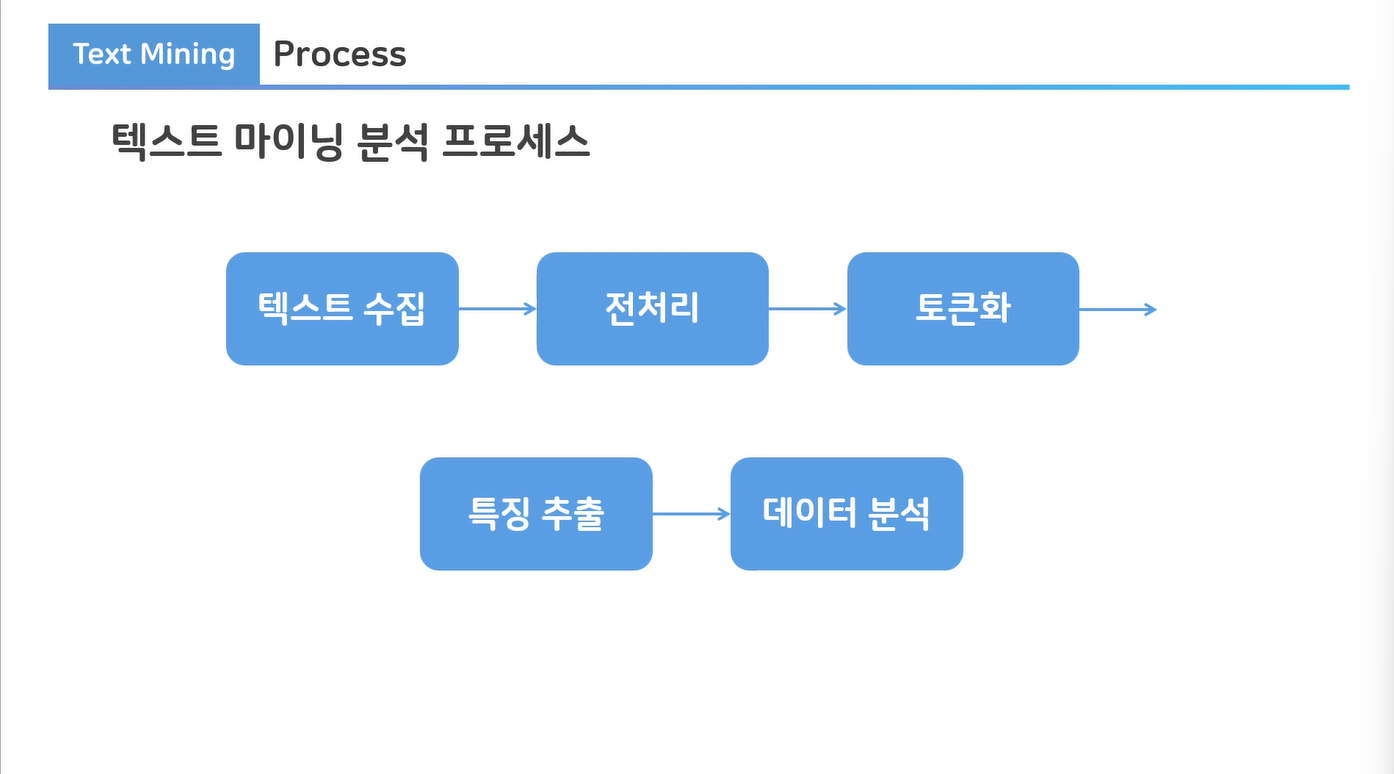
- 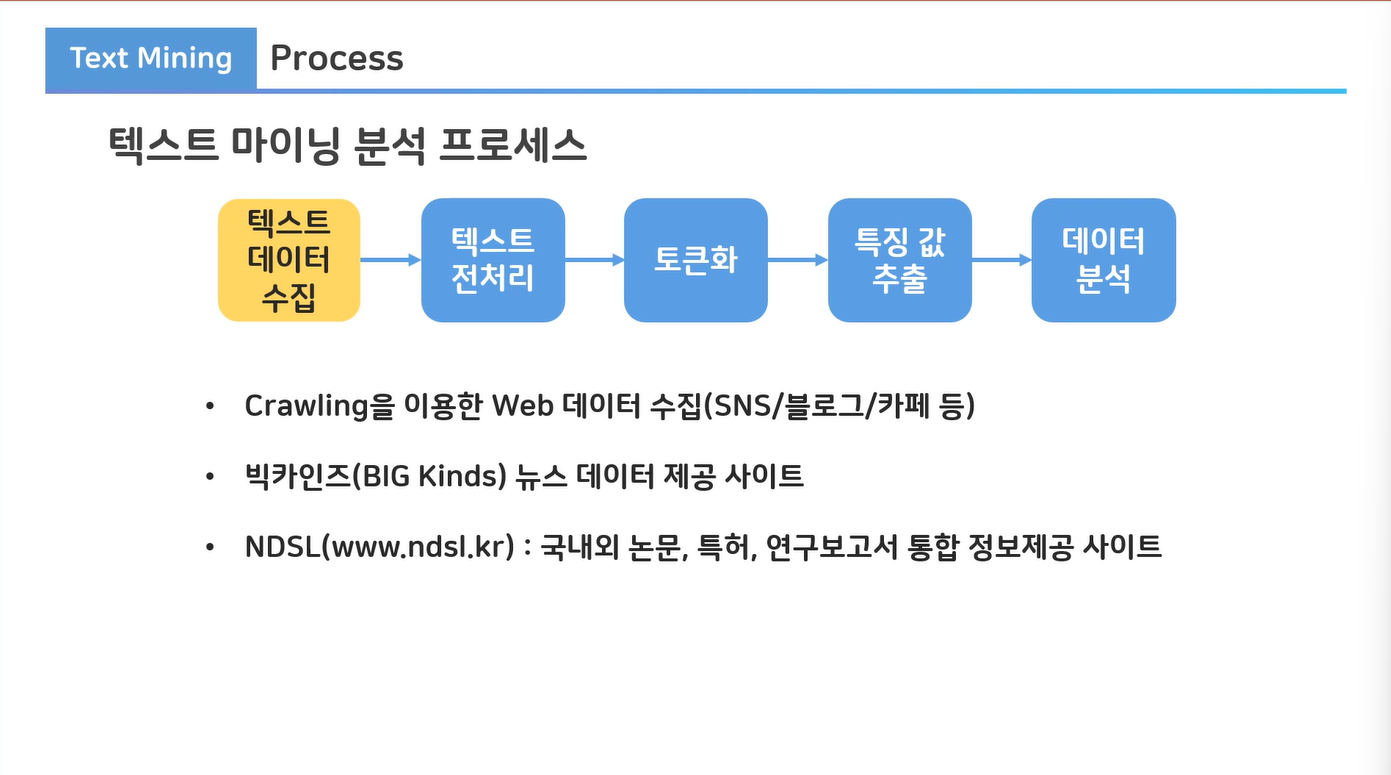
- 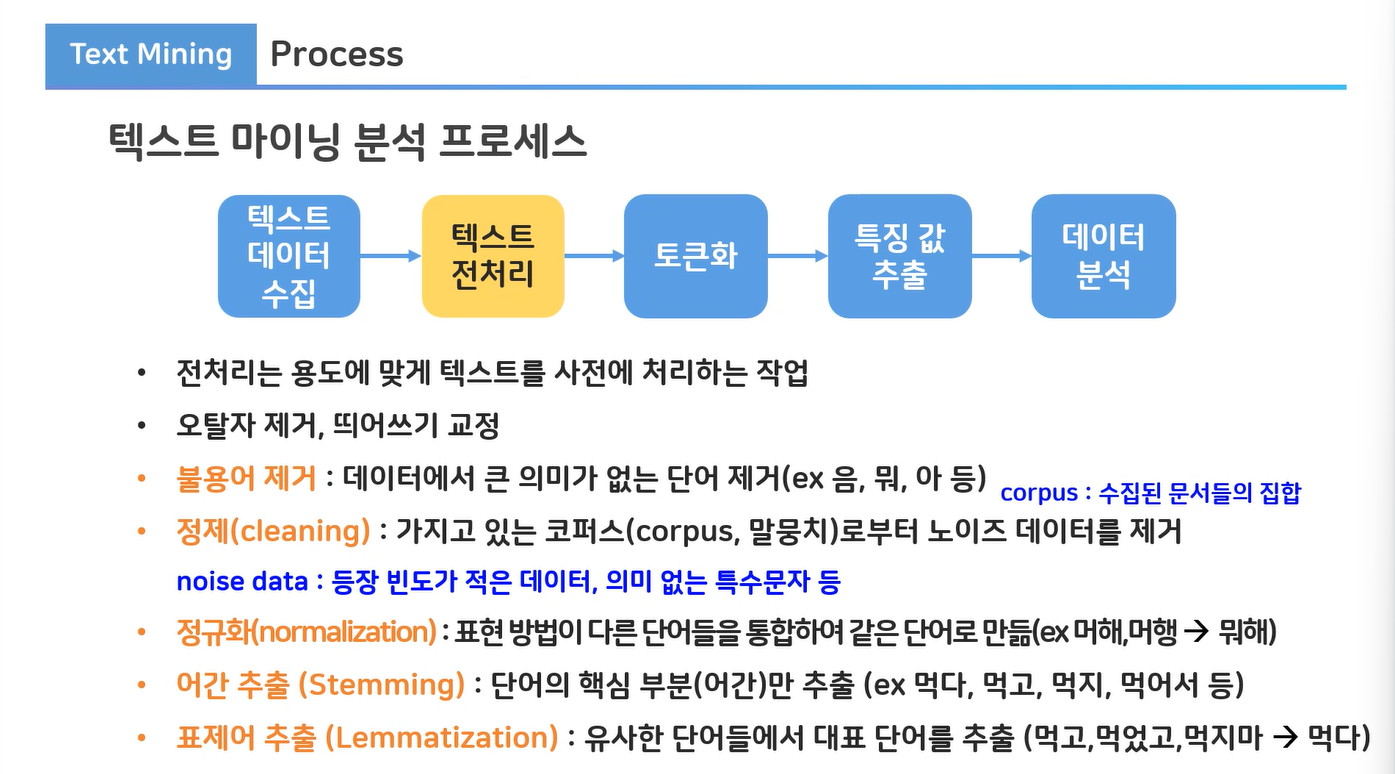
- 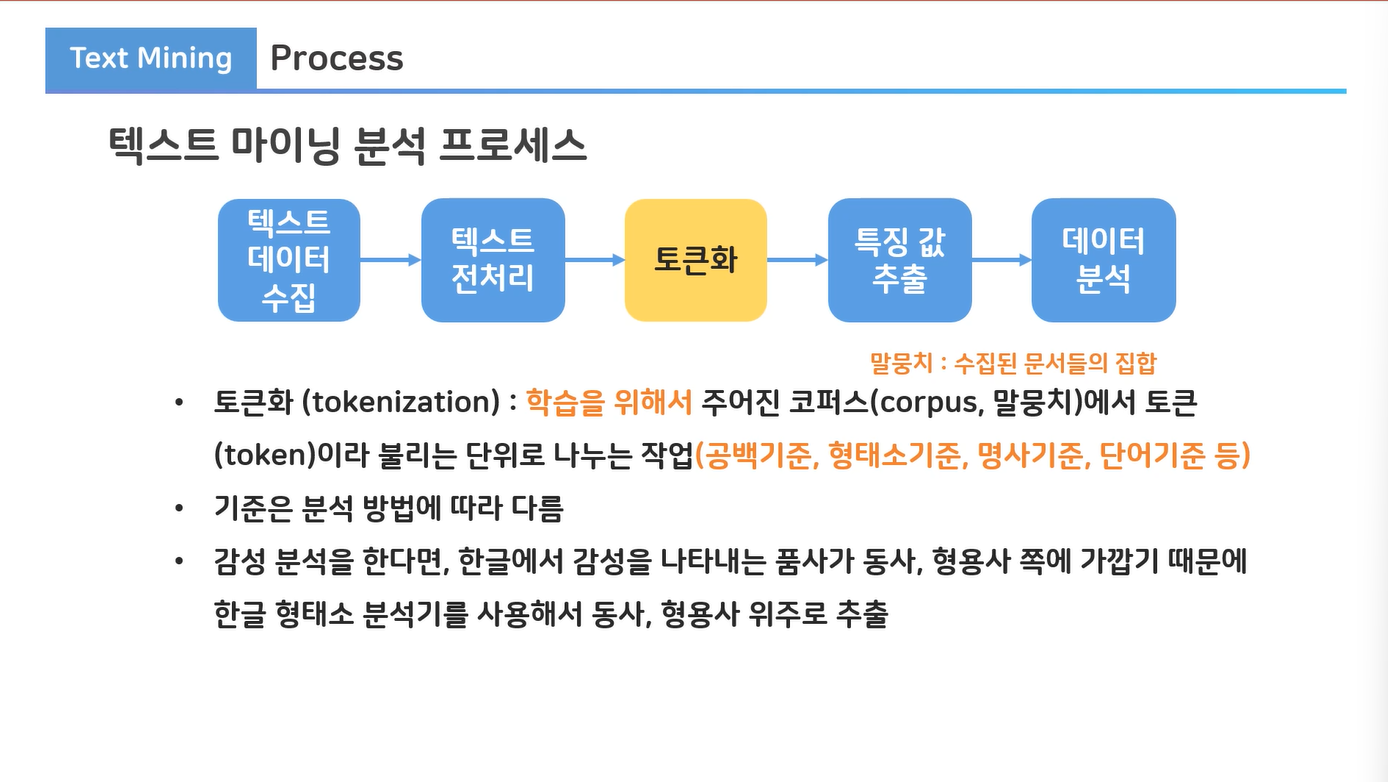
- 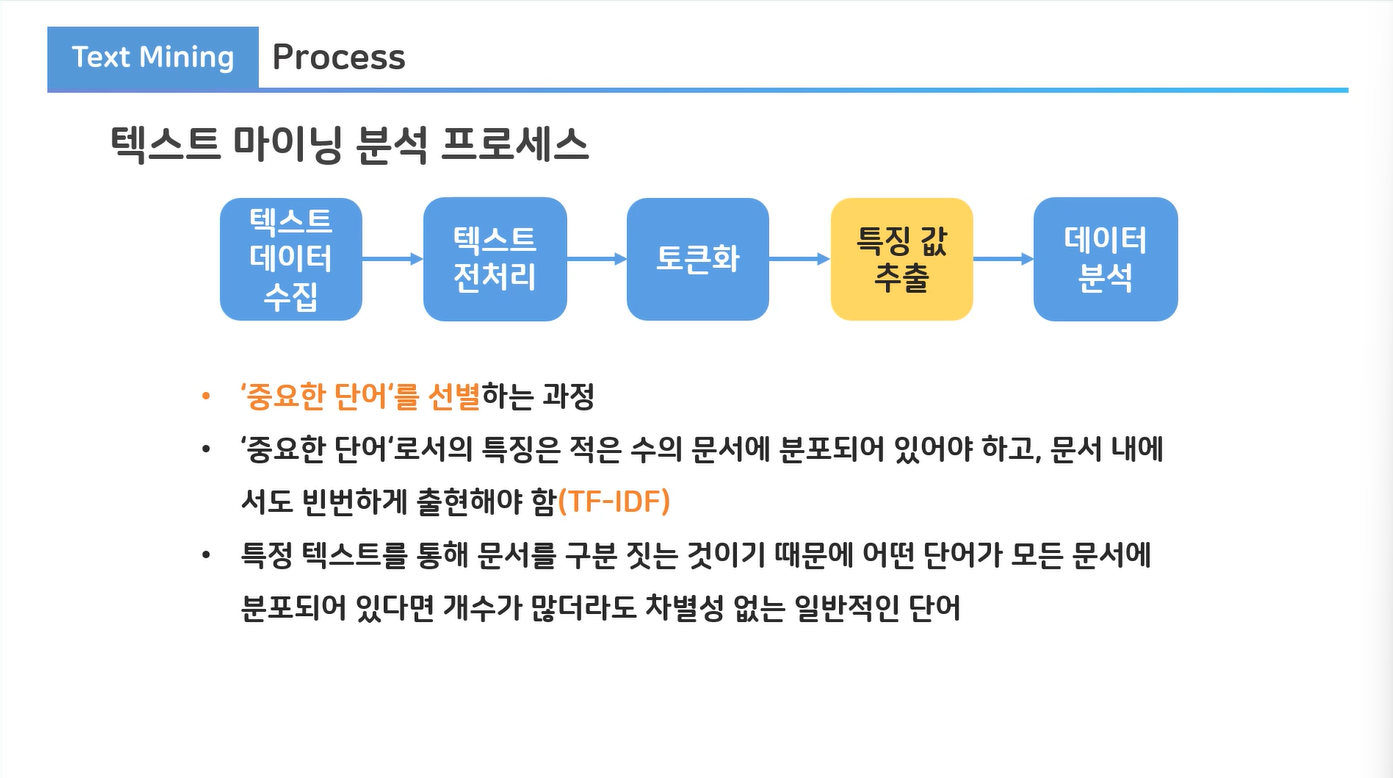
- 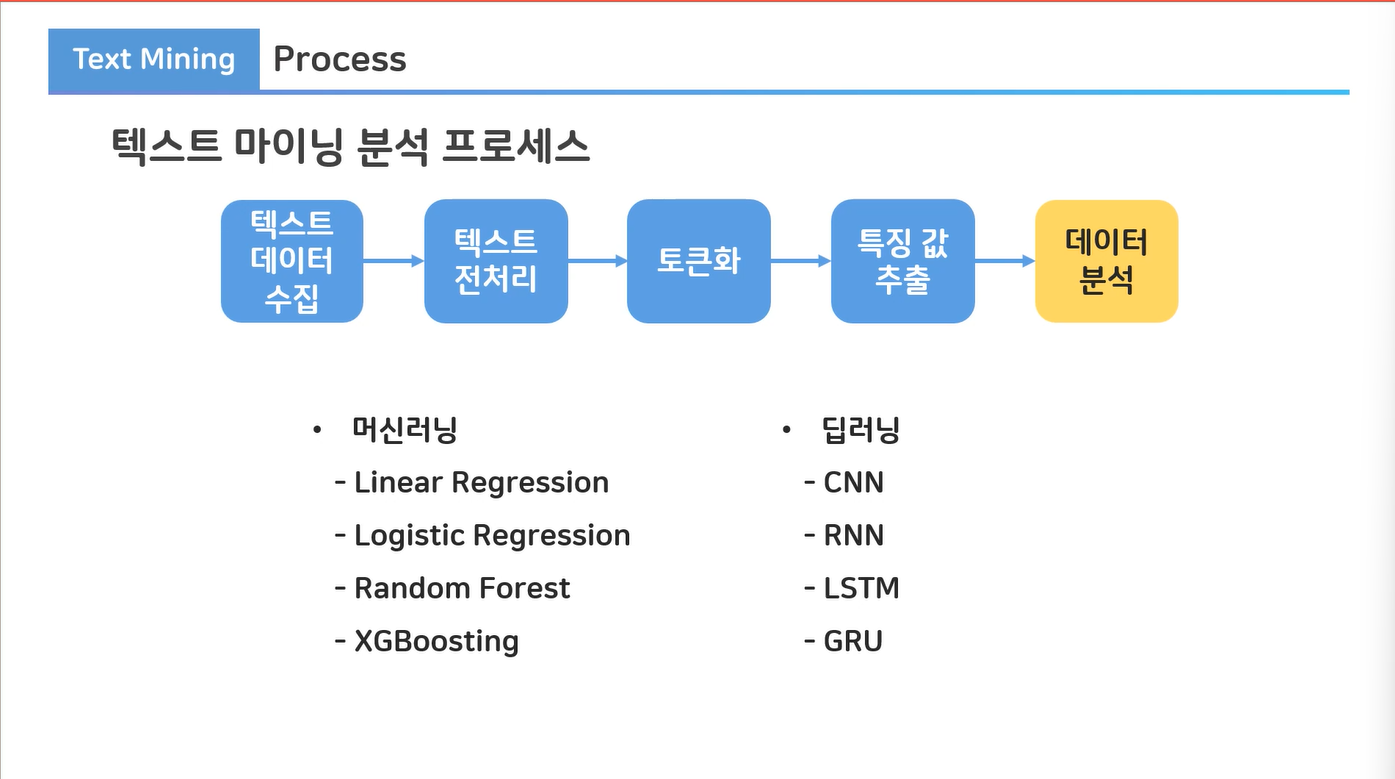

- 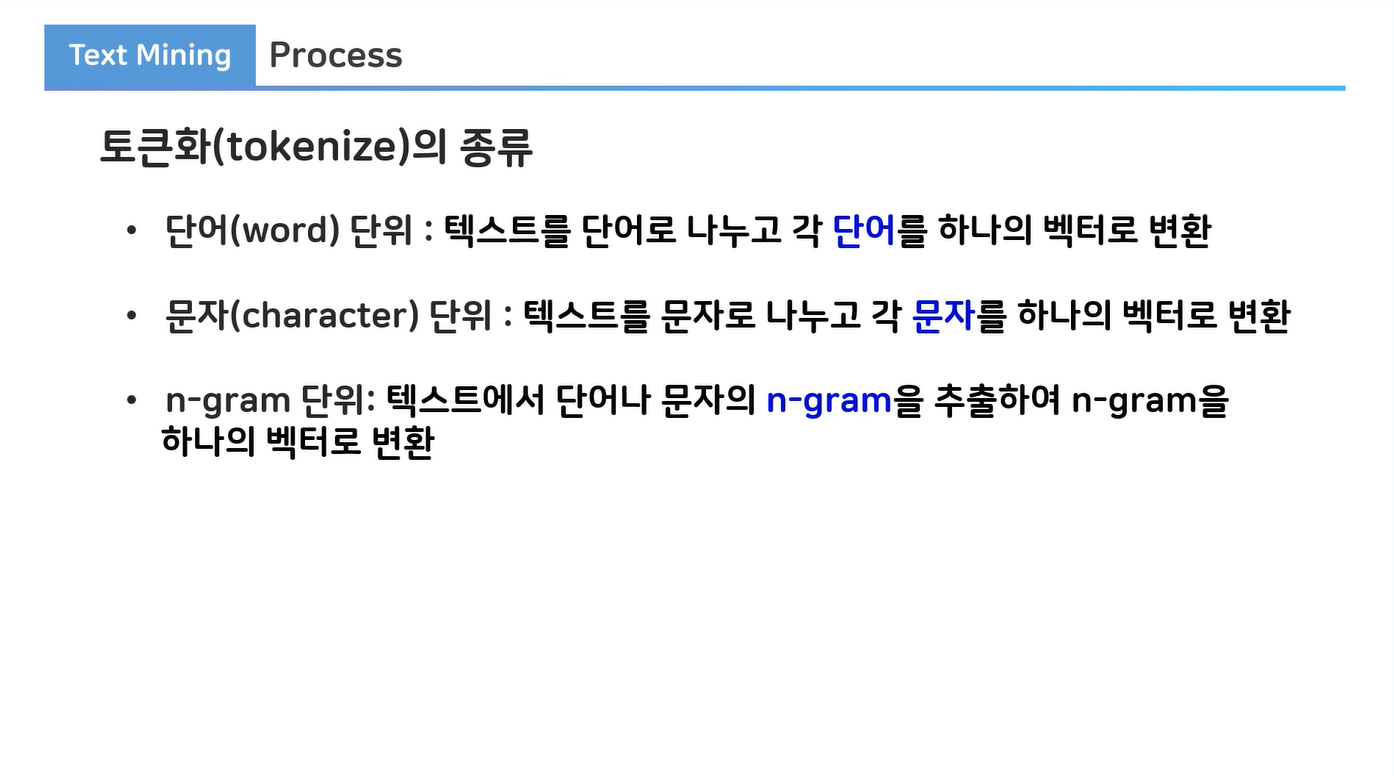 
- 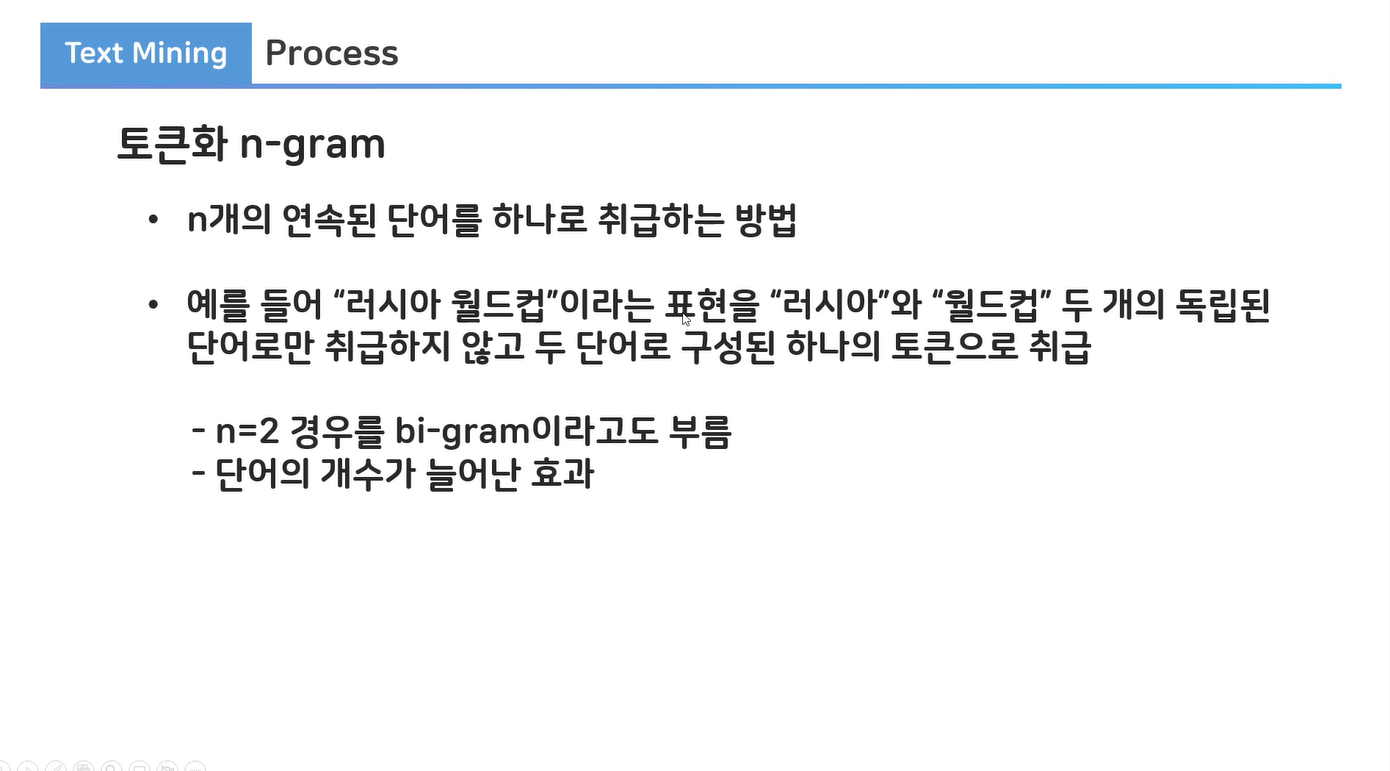
- 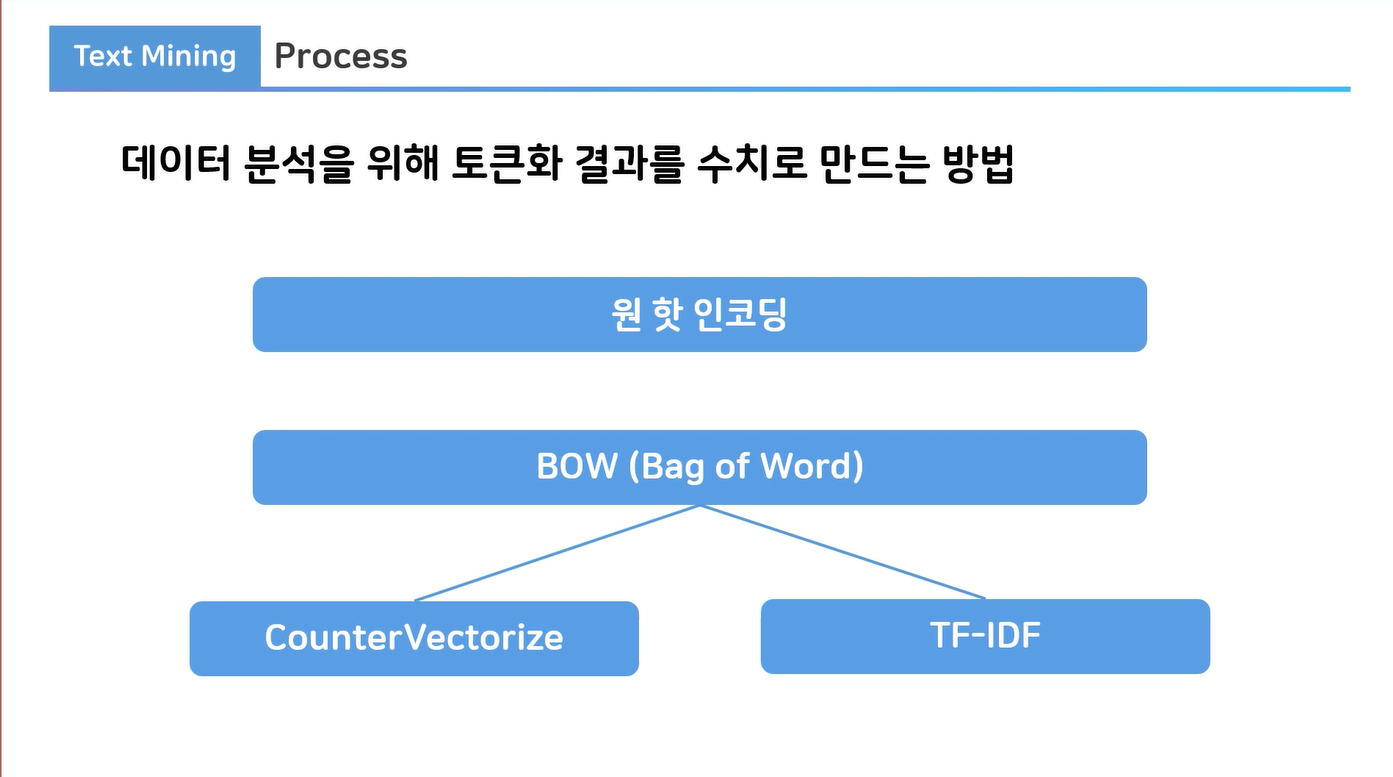
- 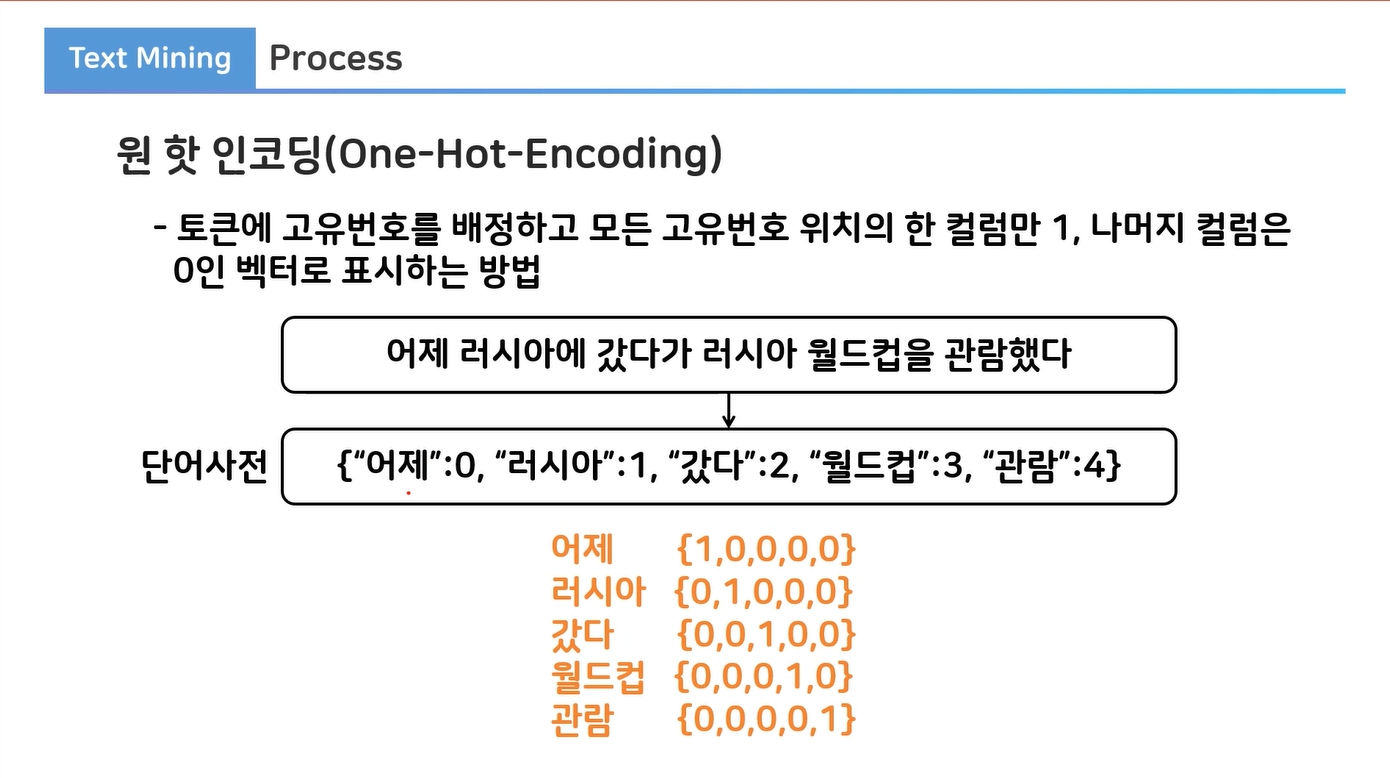
- 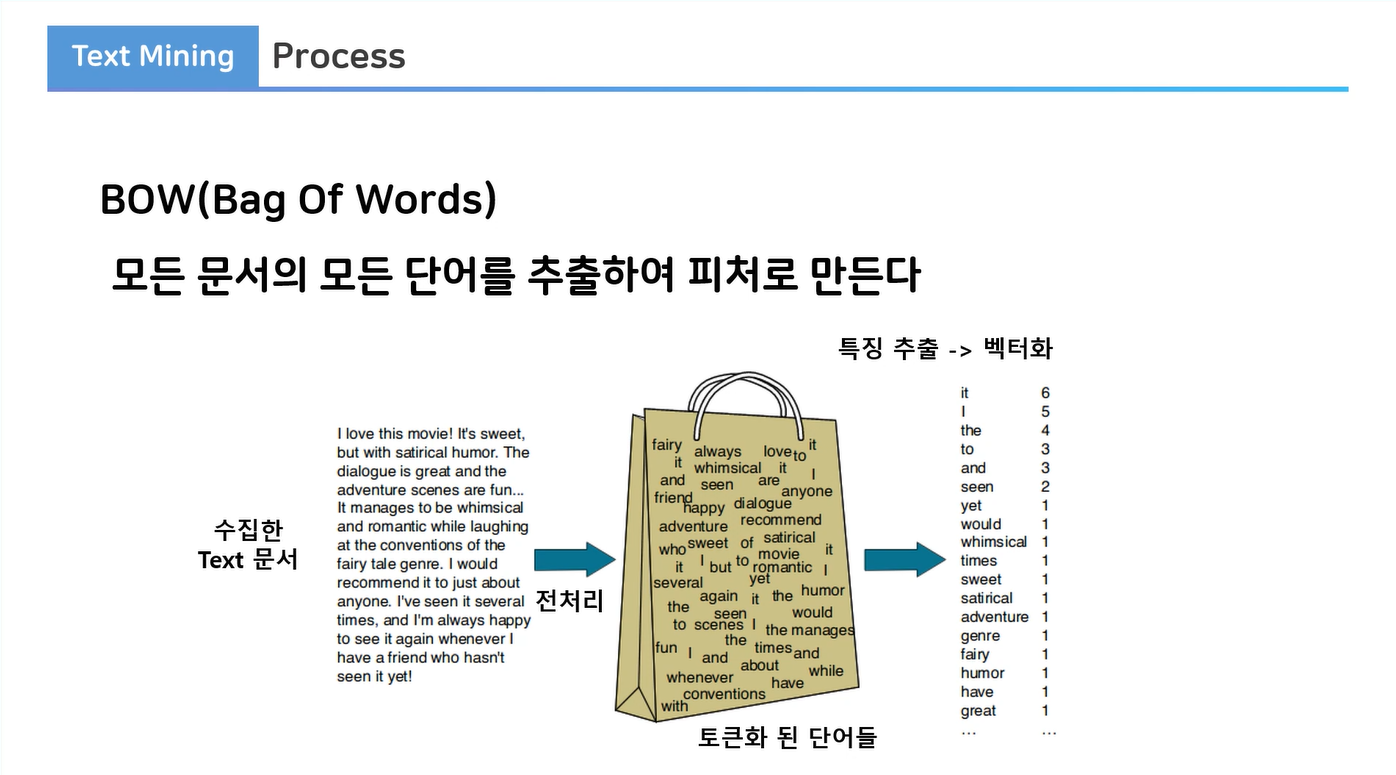
- 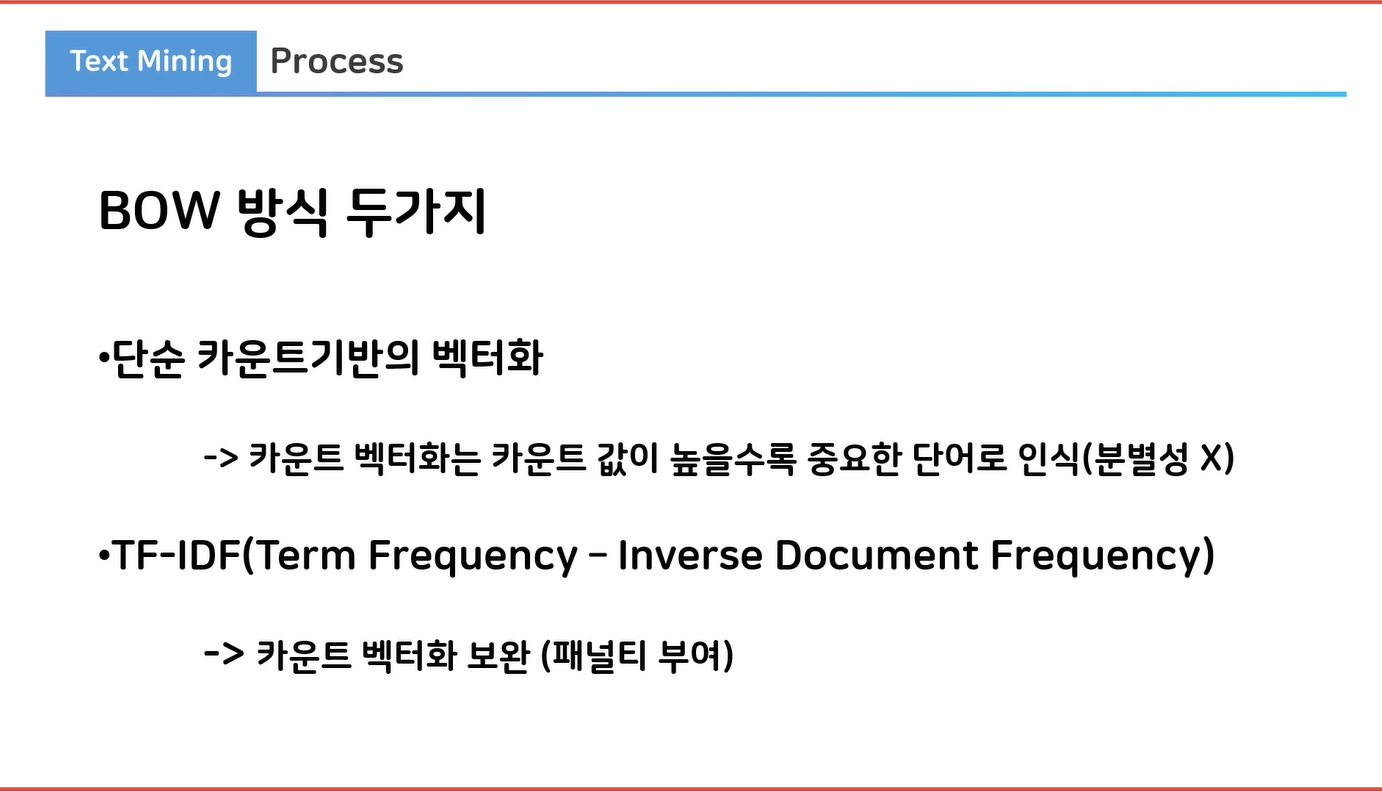

# TextMining
- 비정형 데이터(ex. 텍스트) 에서 의미(인사이트)를 추출하는 작업
- 자연어 처리 기술도 접목해서 최근 많이 수행되고 있음
   - 자연어 처리 : 사람의 언어(텍스트, 음성)를 컴류터가 이해할 수 있도록 처리하는 일련의 과정

## 1.TextMining Process
- 1.1.텍스트 수집
- 1.2.텍스트 정제(전처리)
- 1.3.토큰화
- 1.4.수치화
- 1.5.분석 & 적용 

In [ ]:
# colab 
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# %cd {저장경로}
# /content/drive/MyDrive/Colab Notebooks

### 데이터 수집 및 로딩
- 스마일 게이트의 한국어 혐오표현 데이터셋을 활용
- https://github.com/smilegate-ai/korean_unsmile_dataset

In [7]:
import pandas as pd


train = pd.read_csv("./data/unsmile_train_v1.0.tsv", delimiter="\t")
test = pd.read_csv("./data/unsmile_valid_v1.0.tsv", delimiter="\t")

In [11]:
display(train.head(20))
display(test.head(20))

,문장,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설,clean,개인지칭
0,일안하는 시간은 쉬고싶어서 그런게 아닐까,0,0,0,0,0,0,0,0,0,1,0
1,아동성범죄와 페도버는 기록바 끊어져 영원히 고통 받는다. 무슬림 50퍼 근친이다. ...,0,0,0,0,0,0,1,0,0,0,0
2,루나 솔로앨범 나왔을 때부터 머모 기운 있었음 ㅇㅇ Keep o doin 진짜 띵...,0,0,0,0,0,0,0,0,0,1,0
3,홍팍에도 어버이연합인가 보내요 뭐 이런뎃글 있는데 이거 어버이연합측에 신고하면 그쪽...,0,0,0,0,0,0,0,0,0,1,0
4,아놔 왜 여기 댓들은 다 여자들이 김치녀라고 먼저 불렸다! 여자들은 더 심하게 그런...,1,0,0,0,0,0,0,0,0,0,0
5,고향가서 피방가면 동네 부럴 친구들이랑은 뭐 거르는 거 없이 이야기하니까 막 말하게...,0,0,0,0,0,0,0,0,0,1,0
6,예수 십새끼 개새끼 창녀아들 애비실종 가정교육 못받은 무뇌충 허언증 정신병자 사기꾼...,0,0,0,1,0,1,1,1,0,0,0
7,나이쳐먹고 피시방가는 놈들은 대가리에 똥만찬 놈들임,0,0,0,0,0,0,0,0,1,0,0
8,출산청같은 소리하네. 우리나라 계집들 다 의무적으로 군대보내면 해결될 일이다. 정신...,1,0,0,0,0,0,0,0,0,0,0
9,재능 ㅂㅅㅌㅊ노 ㅋㅋㅋㅋㅋ나도 합성배우고싶다이기,0,0,0,0,0,0,0,0,0,1,0


,문장,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설,clean,개인지칭
0,ㅇㄱㄹㅇ 진짜 죽어도 상관없다는 마인드로 싸웠더니 지금 서열 상타취노 식칼들고 니가...,0,1,0,0,0,0,0,0,0,0,0
1,여자들은 취미가 애낳는건가.. 취미를 좀 가져라,1,0,0,0,0,0,0,0,0,0,0
2,개슬람녀 다 필요없고 니 엄마만 있으면 된다,0,0,0,1,0,0,1,0,0,0,0
3,조팔ㅋㅋ 남한 길거리 돌아다니면 한국남자때문에 눈재기하는데 그걸 내 폰에 굳이 담아...,0,1,0,0,0,0,0,0,0,0,0
4,바지 내리다 한남들 와꾸 보고 올려뿟노,0,1,0,0,0,0,0,0,0,0,0
5,저새끼 슈스케나온새끼잖아 ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ...,0,0,0,0,0,0,0,0,1,0,0
6,모든 이슬람이 테러리스트는 아니지만 모든 테러리스트는 이슬람이다. 자유민주국가에서 ...,0,0,0,1,0,0,1,0,0,0,0
7,또 남자네...? 역시 한남충들은... (절레절레),0,1,0,0,0,0,0,0,0,0,0
8,그만해라 틀딱새끼들 달려와서 너 좆족으로 몰아간다 이제,0,0,0,1,1,0,0,0,0,0,0
9,잘생긴 형같음절대로 여자로 안보임 ㅇㅇ,1,0,0,0,0,0,0,0,0,0,0


In [ ]:
# 결측치 확인 => 특정목적을 가지고 정리한 Data이므로 결측치가 없다.
print(train.isnull().sum(), test.isnull().sum())

문장       0
여성/가족    0
남성       0
성소수자     0
인종/국적    0
연령       0
지역       0
종교       0
기타 혐오    0
악플/욕설    0
clean    0
개인지칭     0
dtype: int64 문장       0
여성/가족    0
남성       0
성소수자     0
인종/국적    0
연령       0
지역       0
종교       0
기타 혐오    0
악플/욕설    0
clean    0
개인지칭     0
dtype: int64


## 2.텍스트 분류
- 텍스트 마이닝 프로세스를 활용해보자!

### 정제(Cleaning)
- 불용어 제거: 불필요한 단어(또는 토큰)를 제거하는 작업
- 어간 추출: 단어의 핵심 부분(어간)만 추출
- 표준어화: 표현 방법을 표준어에 맞춰서 변경

### 정규표현식(Regular Expression)
- 특정한 패턴(규칙)을 가진 문자열의 집합을 표현하는 언어 
- 핸드폰이나 이메일처럼 패턴이 있는 문자열의 검색과 치환을 위해 프로그래밍 언어에서 대부분 지원하고 있다.

In [13]:
# 정규 표현식을 사용할 수 있는 모듈 로딩
import re

In [16]:
# 전화번호 검출 예시

# 휴대폰 번호 형식을 찾기 위한 정규 표현식
p = re.compile("010-?[0-9]{4}-?\\d{4}")

# 010-?[0-9]{4}-?\\d{4} 패턴에 대한 설명:
# 010 : 휴대폰 번호의 첫 세자라(010으로 시작)
# -? : 하이픈(-)이 있을 수도 있고 없을 수도 있다.(선택적)
# [0-9]{4}: 네 자리 숫자(0부터 9까지의 숫자가 4번 반복됨
# -?: 하이픈(-)이 있을 수도 있고 없을 수도 있음(선택적)
# \\d{4} : 숫자 4개(\\d는 숫자 하나를 의미, {4}는 4번 반복됨)
# 010-1234-5678 / 010-12345678 / 01012345678 

In [ ]:
# 적용되는 예시
p.search("전화번호: 010-1234-5678")

<re.Match object; span=(6, 19), match='010-1234-5678'>

In [ ]:
# 적용되지 않는 예시 => 가운데 4자리 고정이므로 출력이 안됨
p.search("전화번호: 010-123-5678")

## 혐오표현 데이터 클렌징
- ㅋㅋㅋ, ㅎㅎㅎ, ㄷㄷㄷ, ㅇㅇ 같이 정해진 횟수 없이 반복되는 글자 삭제 -> 정규표현식 활용

In [21]:
# 패턴생성
p = re.compile("[ㅋㅎㄷㅇ~!?.\\-ㅡ0-ㅔa-z]+")

# 정규 표현식 패턴 설명:
# "[...]": 대괄호 내부에 포함된 문자 중 하나와 일치하는 문자들을 의미
# "ㅋㅎㄷㅇ": "ㅋ", "ㅎ", "ㄷ", "ㅇ", 중 하나의 문자가 들어간 부분을 매칭
# 한국어에서 자주 쓰이는 인터넷 표현: ㅋㅋ, ㅎㅎ, ㄷㄷ, ㅇㅇ
# "~!?.\\-" : 틸트(~), 느낌표(!), 물음표(?), 마침표(.), 하이픈(-) 중 하나와 일치
#          여기서 "\\" 는 이스케이프 문자로, "\-" 을 문자 그대로 인식하도록 처리
# "ㅡ" : 한글 모음 "ㅡ" 를 포함
# "0~9" : 0부터 9까지의 숫자 중 하나와 일피
# "a-z" : 소문자 알파벳 (a부터 z까지) 중 하나와 일치
# "+" : 해당 문자 집합이 한번 이상 반복될 수 있음을 의미 

In [23]:
# 전처리 클랜징 
train_clean = [] # 전처리된 전체 텍스트를 담을 리스트

for doc in train["문장"]: 
    temp = [] # 전처리된 문장의 토큰들이 들어갈 리스트
    for token in doc.split(" "): # 한개의 문장을 토큰화하여 반복
        if len(token) < 2: # 1 글자 제거
            continue
        if p.search(token): # 정규표현식 패턴에 매칭되는지 확인
            continue
        temp.append(token)
    train_clean.append(" ".join(temp)) # 정상적인 토큰을 전체 리스트에 추가


In [25]:
train_clean

['일안하는 시간은 쉬고싶어서 그런게 아닐까',
 '아동성범죄와 페도버는 기록바 끊어져 영원히 고통 무슬림 떨어지고 출산 위험은',
 '루나 솔로앨범 나왔을 때부터 머모 기운 있었음 진짜 띵곡임 들어보셈"',
 '홍팍에도 어버이연합인가 보내요 이런뎃글 있는데 이거 어버이연합측에 신고하면 그쪽에서 고소',
 '아놔 여기 댓들은 여자들이 김치녀라고 먼저 여자들은 심하게 이렇게 내가 둘다 나쁜 이상도 이하도 아닌데',
 '고향가서 피방가면 동네 부럴 친구들이랑은 거르는 없이 이야기하니까 말하게 되더라 당연히 키보드를 치거나 그러지는 않는데 말하는게 많이 거칠어지긴 반성해야겠네',
 '예수 십새끼 개새끼 창녀아들 애비실종 가정교육 못받은 무뇌충 허언증 정신병자 사기꾼 망상 근본없는 병신 장애인 짱개 흑인 이슬람 전라도랑 동급',
 '나이쳐먹고 피시방가는 놈들은 대가리에 똥만찬 놈들임',
 '출산청같은 우리나라 계집들 의무적으로 군대보내면 해결될 정신개조부터 지할꺼 다하고 무슨 애를 낳고 무슨 자식교육을',
 '재능 합성배우고싶다이기',
 '가짜 남자는 어떻게',
 '이슬람뺨치내',
 '어린이집에 월요일에 데려다주고 금요일에 데리고 가슴이 너무 아가가 얼마나',
 '갓슬람 정희구현 테러 테러가 답이다좆같은 양키 씨발새끼들',
 '따고 넘어갔나보네',
 '리더십, 메시지로 내부 결속을 강화하고 외부로 이미지를 구축하여 다시 교회로 모일수 있기를 소망하고 기도합니다',
 '협박스킬은 패시브랑께',
 '위로와 격려를 호텔에서 저여자도 정상은 아니구만 완전 지네 할아버지보다 나이가 많을듯한데 둘다 그렇게 더러운짓은 하고 설교를 어떻게',
 '메틸 알콜 집에서 쓰고 질문 에틸에 메틸 공업용 에틸 알콜은 면세라 불법적으로 술제조 때문에 정도 메틸이 들어가면서 제조방지용으로',
 '띄울사람이 진짜 없긴 없나보다',
 '수준',
 '구구절절 팩트',
 '빼고 아무것도 없는 개돼지 정권이노 탄핵 개힘조',
 '진짜 저것들 아주 싫다, 내가 외국년놈들에게 욕질 괜히 해대는',
 '이슬람

In [26]:
test_clean = []

for doc in test["문장"]:
    temp = []
    for token in doc.split(" "):
        if len(token) < 2:
            continue
        if p.search(token):
            continue
        temp.append(token)
    test_clean.append(" ".join(temp))

In [27]:
test_clean

['진짜 죽어도 상관없다는 마인드로 싸웠더니 지금 서열 상타취노 식칼들고 니가 안찌르면 내가 찌른다 했더니 애비충 냄동충 알아서기노 한번 서열 잡고 담에 개길때마다 세게나가면 확실하게 짓누를수있다익이',
 '여자들은 취미가 취미를 가져라',
 '개슬람녀 필요없고 엄마만 있으면 된다',
 '남한 길거리 돌아다니면 한국남자때문에 눈재기하는데 그걸 폰에 굳이 담아야하노',
 '바지 내리다 한남들 와꾸 보고 올려뿟노',
 '저새끼 슈스케나온새끼잖아',
 '모든 이슬람이 테러리스트는 아니지만 모든 테러리스트는 자유민주국가에서 테러분자 감시는 텄고요, 막는게 최선',
 '역시 (절레절레)',
 '그만해라 틀딱새끼들 달려와서 좆족으로 몰아간다 이제',
 '잘생긴 형같음절대로 여자로 안보임',
 '여성혐오도 아니고 상식 비상식의 저게 한국사회의 약이되는거지 독이 될거라고 생각하는건 대가리좀 깨라',
 '오히려 태평양 패권을 두고 싸운 일본넘들이 두렵게 느껴지는게 정상인데',
 '전라도 통수쩌는 위선자들',
 '두번째는 펨섭이라그래',
 '민주화보소',
 '동성애로 인해 에이즈질환이 급증했는데 본인한테도 피해 타인한테도 동성애는 분명한 죄, 회개하지 않으면 멸망한다고 하나님이',
 '림종석 림수경 수상하지',
 '팩트라 반박은 하고 부들대는 김치좆 답노',
 '저런 불만이 있을테니 외국인들 자동가입 안되게해서 보험료 적용 못받게 해야지 그래야 감기나 배탈로 병원갔다가 병원비랑 약값 보고 식겁해 공단 뛰어가 가입시켜달라고',
 '재크 나이프 하니까 진중곤이 생각나네요',
 '으이고,,누가 그러케 걸래같이 놀리렛나요 남자는 이래서 조신헤야함니다',
 '유튜브 캡쳐 팩트이게 일베저장소 수준',
 '똥남아 다운화 다추방해라 진짜 자지새끼들 딸딸이나치지 없는형편에 아무구멍에라도 박아보겠다고 똥남아새끼들 수입해와서 박아대고 좆같네진짜 씹새끼들',
 '야이 점쟁이새끼야 더러운글 그만올리고점사나 잘봐라',
 '친구먹자 아무것도 하지 않고 썩은 고기나 찾는 하이에나 부대나 인정해라, 당신들의

### 형태소 분석
- Konlpy
- 한국어 : Konlpy(Okt, Kkma, Komoran 등)
- 영어 : NLTK등 

| 분석기    | 속도        | 정확도        | 특징                                                         | 장단점                                                         |
|-----------|-------------|---------------|--------------------------------------------------------------|----------------------------------------------------------------|
| **Mecab** | 매우 빠름   | 높음          | - 백터 기반의 빠른 분석<br>- 대용량 데이터 처리에 적합          | + **장점:** 속도 및 효율성 우수<br>- **단점:** 설치가 다소 복잡, 사전 관리 필요 |
| **Kkma**  | 느림        | 높음          | - 문장 단위의 세밀한 분석 제공<br>- 다양한 형태소 정보 리턴       | + **장점:** 상세 분석, 문맥 파악 용이<br>- **단점:** 속도 느림, 대용량 데이터에 부적합 |
| **Hannanum** | 보통     | 중간          | - KAIST 개발 분석기로 전통적 접근법 사용<br>- 기본 문법 규칙 기반  | + **장점:** 비교적 안정적인 결과 제공<br>- **단점:** 문맥 반영 미흡, 업데이트 한계  |
| **Komoran** | 보통       | 높음          | - 최신 알고리즘 일부 적용<br>- 딥러닝 요소 도입 가능             | + **장점:** 높은 정확도, 견고한 성능<br>- **단점:** 옵션 및 커스터마이징 제한       |
| **Okt**   | 빠름        | 중간 ~ 높음   | - 소셜 미디어(예: 트위터) 문체에 최적화<br>- 감성 분석 등 특화       | + **장점:** 사용법 간편, 빠른 처리<br>- **단점:** 복잡한 문장 분석에는 한계, 단어 세분화 미흡 |
 
---
 
| 형태소 분석기                | 주요 메서드 및 인자                                            | 인자 설명                                                                                                 |
|-----------------------------|--------------------------------------------------------------|-----------------------------------------------------------------------------------------------------------|
| **Hannanum**                | - `pos(phrase, ntags=9, flatten=True)`                         | - **ntags**: 태그의 상세도를 지정 (일반적으로 9 또는 22 사용) <br> - **flatten**: 결과를 단일 리스트로 반환 여부  |
|                             | - `analyze(phrase)`                                             | - 후보 분석 결과(여러 형태소 분석 후보)를 반환                                                              |
| **Kkma**                    | - `pos(phrase, flatten=True)`                                  | - **flatten**: 결과를 평탄화하여 하나의 리스트로 반환                                                         |
|                             | - `sentences(phrase)`                                          | - 입력 텍스트를 문장 단위로 분리하여 리스트로 반환                                                            |
|                             | - `nouns(phrase)`, `morphs(phrase)`                              | - 각각 명사와 모든 형태소만을 추출                                                                           |
| **Komoran**                 | - `pos(phrase, flatten=True)`                                  | - **flatten**: 결과를 단일 리스트로 반환 여부                                                                 |
|                             | - `nouns(phrase)`, `morphs(phrase)`                              | - 각각 명사와 모든 형태소만을 추출                                                                           |
| **Mecab**                   | - `pos(phrase, flatten=True)`                                  | - **flatten**: 결과를 평탄화하여 하나의 리스트로 반환                                                         |
|                             | - `nouns(phrase)`, `morphs(phrase)`                              | - 각각 명사와 모든 형태소만을 추출                                                                           |
| **Okt (Open Korean Text)**  | - `pos(phrase, norm=False, stem=False)`                        | - **norm**: 정규화 여부 (예: 숫자, 영문 등의 표준 형태로 변환할지 결정) <br> - **stem**: 어간 추출 여부 (어근화)  |
|                             | - `phrases(phrase)`                                            | - 텍스트 내 구(phrase)를 추출                                                                               |
|                             | - `nouns(phrase)`, `morphs(phrase)`                              | - 각각 명사와 모든 형태소만을 추출                                                                           |
 

In [29]:
!pip -q install konlpy


In [ ]:
from konlpy.tag import Okt, kkma